# The Syndrome Algebra — Step-by-Step Construction

Companion notebook to:

- **The Syndrome Algebra for Differentiable Parametric Systems**
- **Three Measurable Failure Modes of Large Language Models**

This notebook walks through the syndrome-algebra construction for two matrices — a 3×3 square matrix and a 3×4 asymmetric matrix — with full symbolic derivation for the linear case and numerical evaluation for the nonlinear (tanh) case. Run all cells top to bottom.

In [1]:
# ===============================================================
# Imports and display helpers
# ===============================================================

import numpy as np
import sympy as sp
from sympy import Matrix, symbols, sqrt, Rational, simplify, latex
from sympy import tanh as sp_tanh, diff, Symbol
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import display, Math, Markdown
matplotlib.rcParams['figure.dpi'] = 100

def show(expr, label=None):
    """Display a sympy expression as LaTeX with optional label."""
    if label:
        display(Math(rf'{label} = {latex(expr)}'))
    else:
        display(Math(latex(expr)))

def header(text):
    display(Markdown(f'### {text}'))

def step(n, text):
    display(Markdown(f'**Step {n}:** {text}'))

def note(text):
    display(Markdown(f'> *{text}*'))


In [2]:
# ===============================================================
# INPUT CELL — edit this cell to use your own matrices
# ===============================================================

# Toggle: full symbolic tanh expressions are long. Default: False.
SHOW_SYMBOLIC_NONLINEAR = False

# 3x3 matrix — three distinct nonzero singular values.
W_sq_num = np.array([
    [3.0, 1.0, 0.5],
    [0.0, 2.0, 1.0],
    [0.5, 0.0, 1.5],
], dtype=float)

W_sq_sym = Matrix([
    [3, 1, sp.Rational(1, 2)],
    [0, 2, 1],
    [sp.Rational(1, 2), 0, sp.Rational(3, 2)],
])

# 3x4 matrix — d_out=3 < d_in=4 guarantees sigma_4 = 0 exactly.
W_rect_num = np.array([
    [2.0, 1.0, 0.5, 0.0],
    [0.0, 3.0, 1.0, 0.5],
    [1.0, 0.0, 2.0, 1.0],
], dtype=float)

W_rect_sym = Matrix([
    [2, 1, sp.Rational(1, 2), 0],
    [0, 3, 1, sp.Rational(1, 2)],
    [1, 0, 2, 1],
])

# Probes for nonlinear (tanh) syndrome computation.
PROBES_3 = np.array([
    [1, 0, 0], [0, 1, 0], [0, 0, 1],
    [1, 1, 0], [1, 0, 1], [0, 1, 1],
    [1, 1, 1],
], dtype=float)

PROBES_4 = np.array([
    [1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1],
    [1, 1, 0, 0], [0, 1, 1, 0], [1, 0, 0, 1],
], dtype=float)

# Perturbation settings (Part III)
INJECT_K   = 0     # which SVD direction to inject (0-indexed)
EPS_INJECT = 2.0   # perturbation magnitude
WRONG_J    = 1     # wrong correction direction for crossing-error demo

# OOD probe (Part IV)
OOD_PROBE_4 = np.array([5.0, -3.0, 2.0, 4.0])


In [3]:
display(Markdown('---'))
display(Markdown('## Part I — Square Matrix (3×3)'))
display(Markdown(
    'We construct the syndrome table for a 3×3 weight matrix. '
    'Three input dimensions, three output dimensions. The Gram '
    'metric $G = W^\\top W$ is a 3×3 matrix whose eigenvectors give the '
    'natural perturbation basis.'
))


---

## Part I — Square Matrix (3×3)

We construct the syndrome table for a 3×3 weight matrix. Three input dimensions, three output dimensions. The Gram metric $G = W^\top W$ is a 3×3 matrix whose eigenvectors give the natural perturbation basis.

In [4]:
step(1, 'The weight matrix W')
note('This is the matrix whose syndrome table we will construct. '
     'Each column is one input dimension; each row is one output dimension.')

show(W_sq_sym, 'W')
print('\nNumerical values:')
print(np.array2string(W_sq_num, precision=4, suppress_small=True))


**Step 1:** The weight matrix W

> *This is the matrix whose syndrome table we will construct. Each column is one input dimension; each row is one output dimension.*

<IPython.core.display.Math object>


Numerical values:
[[3.  1.  0.5]
 [0.  2.  1. ]
 [0.5 0.  1.5]]


In [5]:
step(2, 'Gram matrix G = WᵀW')
note('G is the Riemannian metric on the parameter subspace. '
     'Its eigenvalues are the squared singular values σ_k². '
     'High eigenvalue = signal direction. Near-zero = null space.')

G_sym = W_sq_sym.T * W_sq_sym
G_sym = simplify(G_sym)
show(G_sym, 'G = W^\\top W')

G_num = W_sq_num.T @ W_sq_num
print('\nNumerical G:')
print(np.array2string(G_num, precision=4))


**Step 2:** Gram matrix G = WᵀW

> *G is the Riemannian metric on the parameter subspace. Its eigenvalues are the squared singular values σ_k². High eigenvalue = signal direction. Near-zero = null space.*

<IPython.core.display.Math object>


Numerical G:
[[9.25 3.   2.25]
 [3.   5.   2.5 ]
 [2.25 2.5  3.5 ]]


In [6]:
step(3, 'Characteristic polynomial and eigenvalues of G')
note('The eigenvalues of G are σ_k². Their square roots are the '
     'singular values of W. Directions with σ_k ≈ 0 are the null space.')

lam = sp.Symbol('lambda')
char_poly = G_sym.charpoly(lam)
display(Math(rf'\det(G - \lambda I) = {latex(char_poly.as_expr())}'))

eigenvals = G_sym.eigenvals()
display(Markdown('**Eigenvalues (= σ_k²):**'))
sorted_eigs = sorted(eigenvals.items(),
                     key=lambda item: complex(item[0].evalf()).real,
                     reverse=True)
for i, (val, mult) in enumerate(sorted_eigs):
    val_num = complex(val.evalf()).real
    sigma = complex(sp.sqrt(val).evalf()).real
    display(Math(
        rf'\lambda_{i+1} = {latex(simplify(val))} \approx {val_num:.4f}'
        rf'\quad \Rightarrow \quad \sigma_{i+1} \approx {sigma:.4f}'
    ))


**Step 3:** Characteristic polynomial and eigenvalues of G

> *The eigenvalues of G are σ_k². Their square roots are the singular values of W. Directions with σ_k ≈ 0 are the null space.*

<IPython.core.display.Math object>

**Eigenvalues (= σ_k²):**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
step(4, 'Singular Value Decomposition: W = UΣVᵀ')
note('The right singular vectors V (columns of V) are the eigenvectors '
     'of G = WᵀW. They form the natural perturbation basis — the '
     'directions in which we perturb W to build the syndrome table.')

U, S_vals, Vt = np.linalg.svd(W_sq_num)
V = Vt.T

display(Markdown('**Singular values (σ₁ ≥ σ₂ ≥ σ₃):**'))
for i, s in enumerate(S_vals):
    print(f'  σ_{i+1} = {s:.6f}')

display(Markdown('**Right singular vectors (columns of V = rows of Vᵀ):**'))
print('V =')
print(np.array2string(V, precision=4, suppress_small=True))
display(Markdown(
    '*Each column v_k of V is the k-th right singular vector — '
    'the k-th perturbation direction.*'
))


**Step 4:** Singular Value Decomposition: W = UΣVᵀ

> *The right singular vectors V (columns of V) are the eigenvectors of G = WᵀW. They form the natural perturbation basis — the directions in which we perturb W to build the syndrome table.*

**Singular values (σ₁ ≥ σ₂ ≥ σ₃):**

  σ_1 = 3.462775
  σ_2 = 2.029607
  σ_3 = 1.280579


**Right singular vectors (columns of V = rows of Vᵀ):**

V =
[[-0.8073  0.5901 -0.0029]
 [-0.4727 -0.6498 -0.5952]
 [-0.3531 -0.4792  0.8035]]


*Each column v_k of V is the k-th right singular vector — the k-th perturbation direction.*

In [8]:
step(5, 'Signal space and null space classification')
note('Directions with σ_k > threshold are signal space (learned). '
     'Directions with σ_k ≈ 0 are null space (unlearned — the '
     'covert channel).')

THRESHOLD = 0.3   # absolute σ threshold below which we call it null
signal_dirs = []
null_dirs = []
for i, s in enumerate(S_vals):
    category = 'NULL SPACE' if s < THRESHOLD else 'signal space'
    ratio = s / S_vals[0]
    print(f'  v_{i+1}: σ = {s:.4f}  (σ/σ₁ = {ratio:.3f})  → {category}')
    (null_dirs if s < THRESHOLD else signal_dirs).append(i)

if null_dirs:
    display(Markdown(
        f'**Null space directions:** {[f"v_{i+1}" for i in null_dirs]}'
    ))
else:
    display(Markdown(
        '**No exact null directions** in this 3×3 matrix '
        '(all σ_k > 0). The 3×4 case in Part II will show an '
        'exact null direction by construction.'
    ))

# Cache for Part II reference
S_vals_sq = S_vals


**Step 5:** Signal space and null space classification

> *Directions with σ_k > threshold are signal space (learned). Directions with σ_k ≈ 0 are null space (unlearned — the covert channel).*

  v_1: σ = 3.4628  (σ/σ₁ = 1.000)  → signal space
  v_2: σ = 2.0296  (σ/σ₁ = 0.586)  → signal space
  v_3: σ = 1.2806  (σ/σ₁ = 0.370)  → signal space


**No exact null directions** in this 3×3 matrix (all σ_k > 0). The 3×4 case in Part II will show an exact null direction by construction.

In [9]:
step(6, 'Jacobian of the output with respect to W (linear case)')
note('For the linear system ℓ(x; W) = Wx, the Jacobian is: '
     'J(x)_{a,μ} = ∂ℓ^a / ∂W_{a,μ} = x_μ. '
     'The output change when W is perturbed by ΔW = ε·v_k·1ᵀ is: '
     'δℓ(x) = ε·J(x)·v_k = ε·(xᵀv_k)·1.')

x1, x2, x3 = sp.symbols('x_1 x_2 x_3')
x_sym = Matrix([x1, x2, x3])

display(Markdown('**Symbolic probe vector:**'))
show(x_sym, 'x')

display(Markdown('**First right singular vector v₁ (numerical → rational approx):**'))
v1_display = Matrix([sp.nsimplify(v, rational=True, tolerance=0.01)
                     for v in V[:, 0]])
show(v1_display, 'v_1')

display(Markdown('**Output change δℓ(x) = ε·(xᵀv₁)·1 for the linear system:**'))
dot_scalar = (x_sym.T * v1_display)[0, 0]
display(Math(
    rf'\delta\ell(x) = \varepsilon \cdot (x^\top v_1) \cdot \mathbf{{1}}'
    rf' = \varepsilon \cdot \left({latex(dot_scalar)}\right) \cdot \mathbf{{1}}'
))


**Step 6:** Jacobian of the output with respect to W (linear case)

> *For the linear system ℓ(x; W) = Wx, the Jacobian is: J(x)_{a,μ} = ∂ℓ^a / ∂W_{a,μ} = x_μ. The output change when W is perturbed by ΔW = ε·v_k·1ᵀ is: δℓ(x) = ε·J(x)·v_k = ε·(xᵀv_k)·1.*

**Symbolic probe vector:**

<IPython.core.display.Math object>

**First right singular vector v₁ (numerical → rational approx):**

<IPython.core.display.Math object>

**Output change δℓ(x) = ε·(xᵀv₁)·1 for the linear system:**

<IPython.core.display.Math object>

In [10]:
step(7, 'Averaging the Jacobian response over probe inputs')
note('The averaged syndrome is J̄·v_k = (1/n_p) Σ_i δℓ(x_i)/ε. '
     'For a linear system this equals the mean of (x_iᵀv_k) broadcast '
     'to all output dimensions.')

display(Markdown('**Symbolic probe vectors x⁽¹⁾, x⁽²⁾, x⁽³⁾:**'))
probe_syms = [Matrix([sp.Symbol(f'x{i}_{j}') for j in range(1, 4)])
              for i in range(1, 4)]
for i, p in enumerate(probe_syms[:3]):
    show(p.T, f'x^{{({i+1})}}')

display(Markdown('**Individual responses δℓ(x⁽ⁱ⁾)/ε = x_iᵀv_1:**'))
for i, p in enumerate(probe_syms[:3]):
    dot = sum(p[j] * v1_display[j] for j in range(3))
    display(Math(rf'x^{{({i+1})\top}} v_1 = {latex(dot)}'))

display(Markdown('**Averaged response (symbolic mean):**'))
avg_sym = sum(
    sum(probe_syms[i][j] * v1_display[j] for j in range(3))
    for i in range(3)
) / 3
display(Math(
    rf'\bar{{J}} v_1 = \frac{{1}}{{3}}\sum_{{i=1}}^{{3}} x^{{(i)\top}} v_1'
    rf' = \frac{{1}}{{3}}\left({latex(avg_sym * 3)}\right)'
))

display(Markdown('**Numerical evaluation with the seven preset probes:**'))
Jbar_v1_num = float(np.mean(PROBES_3 @ V[:, 0])) * np.ones(3)
print(f'J̄·v₁ (numerical) = {Jbar_v1_num}')


**Step 7:** Averaging the Jacobian response over probe inputs

> *The averaged syndrome is J̄·v_k = (1/n_p) Σ_i δℓ(x_i)/ε. For a linear system this equals the mean of (x_iᵀv_k) broadcast to all output dimensions.*

**Symbolic probe vectors x⁽¹⁾, x⁽²⁾, x⁽³⁾:**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

**Averaged response (symbolic mean):**

<IPython.core.display.Math object>

**Numerical evaluation with the seven preset probes:**

J̄·v₁ (numerical) = [-0.93327175 -0.93327175 -0.93327175]


In [11]:
step(8, 'Computing syndrome entry s₁ = N(J̄·v₁)')
note('Row-wise ℓ₂ normalisation maps J̄·v_k to a unit vector s_k ∈ ℝ³. '
     'This is the k-th row of the syndrome table S.')

# Linear system: δℓ(x) = (xᵀv_k) · 1  ⇒  J̄·v_k = mean_i(x_iᵀ v_k) · 1
Jbar_v1 = float(PROBES_3.mean(axis=0) @ V[:, 0]) * np.ones(3)
norm = float(np.linalg.norm(Jbar_v1))
s1 = Jbar_v1 / norm if norm > 1e-12 else np.zeros(3)

display(Math(
    rf'\bar{{J}} v_1 = {latex(Matrix(list(np.round(Jbar_v1, 4))))}'
))
display(Math(
    rf'\|\bar{{J}} v_1\| = {norm:.4f}'
))
display(Math(
    rf's_1 = \mathcal{{N}}(\bar{{J}} v_1) = '
    rf'{latex(Matrix(list(np.round(s1, 4))))}, \quad \|s_1\| = 1'
))


**Step 8:** Computing syndrome entry s₁ = N(J̄·v₁)

> *Row-wise ℓ₂ normalisation maps J̄·v_k to a unit vector s_k ∈ ℝ³. This is the k-th row of the syndrome table S.*

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [12]:
step(9, 'Full syndrome table S = N(J̄·V)ᵀ (linear case)')
note('Repeat the syndrome computation for all three SVD directions. '
     'Stack as rows. The result is the syndrome table S ∈ ℝ^{3×3}.')

S_linear = np.zeros((3, 3))
for k in range(3):
    Jbar_vk = float(PROBES_3.mean(axis=0) @ V[:, k]) * np.ones(3)
    norm = float(np.linalg.norm(Jbar_vk))
    sk = Jbar_vk / norm if norm > 1e-12 else np.zeros(3)
    S_linear[k] = sk
    display(Math(
        rf's_{k+1} = \mathcal{{N}}(\bar{{J}} v_{k+1}) = '
        rf'{latex(Matrix(list(np.round(sk, 4))))}'
    ))

display(Markdown('**Full linear syndrome table S:**'))
show(Matrix(np.round(S_linear, 4).tolist()), 'S')
note('In the **linear** case every row of S is ±[1,1,1]/√3 (broadcast '
     'by the 1-vector). Linear systems are degenerate — they cannot '
     'distinguish SVD directions by syndrome. The nonlinear case '
     '(next cell) breaks this degeneracy.')


**Step 9:** Full syndrome table S = N(J̄·V)ᵀ (linear case)

> *Repeat the syndrome computation for all three SVD directions. Stack as rows. The result is the syndrome table S ∈ ℝ^{3×3}.*

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Full linear syndrome table S:**

<IPython.core.display.Math object>

> *In the **linear** case every row of S is ±[1,1,1]/√3 (broadcast by the 1-vector). Linear systems are degenerate — they cannot distinguish SVD directions by syndrome. The nonlinear case (next cell) breaks this degeneracy.*

**Step 10:** Nonlinear case: syndrome table with tanh output (numerical)

> *For ℓ(x; W) = tanh(Wx), the Jacobian is J(x) = diag(1 − tanh²(Wx)) · W — input-dependent. The syndrome rows now differ because each probe gives a different local Jacobian.*

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Comparison: linear vs nonlinear syndrome table**

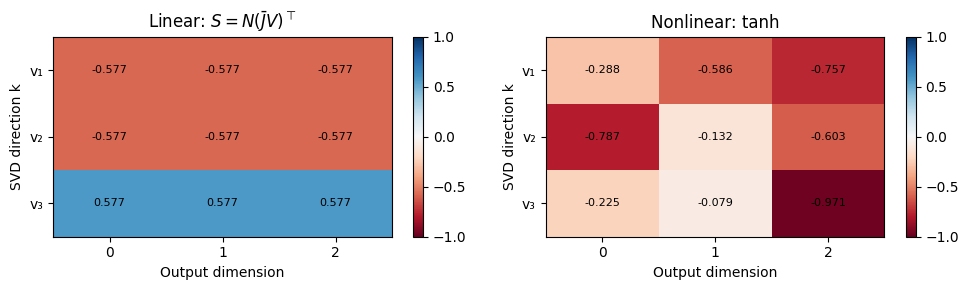

In [13]:
step(10, 'Nonlinear case: syndrome table with tanh output (numerical)')
note('For ℓ(x; W) = tanh(Wx), the Jacobian is '
     'J(x) = diag(1 − tanh²(Wx)) · W — input-dependent. '
     'The syndrome rows now differ because each probe gives a '
     'different local Jacobian.')

def forward_tanh(W, x):
    return np.tanh(W @ x)

def jacobian_tanh(W, x):
    z = W @ x
    d = 1 - np.tanh(z)**2
    return np.diag(d) @ W

def syndrome_nonlinear(W, V, probes, k, eps=2.0):
    """Compute syndrome for direction k via finite difference."""
    vk = V[:, k]
    Wp = W + eps * np.outer(np.ones(W.shape[0]), vk)
    delta = np.mean(
        [forward_tanh(Wp, x) - forward_tanh(W, x) for x in probes],
        axis=0
    )
    mag = float(np.linalg.norm(delta))
    return (delta / mag if mag > 1e-12 else np.zeros_like(delta)), mag

S_nonlinear = np.zeros((3, 3))
for k in range(3):
    sk, mag = syndrome_nonlinear(W_sq_num, V, PROBES_3, k)
    S_nonlinear[k] = sk
    display(Math(
        rf's_{k+1}^{{\tanh}} = {latex(Matrix(list(np.round(sk, 4))))}'
        rf'\quad (\|\delta\| = {mag:.4f})'
    ))

display(Markdown('**Comparison: linear vs nonlinear syndrome table**'))
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, S, title in zip(axes,
                          [S_linear, S_nonlinear],
                          ['Linear: $S = N(\\bar{J}V)^\\top$',
                           'Nonlinear: tanh']):
    im = ax.imshow(S, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Output dimension')
    ax.set_ylabel('SVD direction k')
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_yticklabels(['v₁', 'v₂', 'v₃'])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{S[i,j]:.3f}', ha='center', va='center',
                    fontsize=8, color='black')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [14]:
if SHOW_SYMBOLIC_NONLINEAR:
    step('10b', 'Nonlinear symbolic derivation (SHOW_SYMBOLIC_NONLINEAR = True)')
    note('Full symbolic tanh Jacobian. Expressions are long but fully verifiable.')

    x1s, x2s, x3s = sp.symbols('x_1 x_2 x_3')
    xs = Matrix([x1s, x2s, x3s])

    z_sym = W_sq_sym * xs
    display(Math(rf'z = Wx = {latex(z_sym)}'))

    ell_sym = Matrix([sp.tanh(z_sym[i]) for i in range(3)])
    display(Math(rf'\ell(x; W) = \tanh(Wx) = {latex(ell_sym)}'))

    display(Markdown('**Jacobian J(x)_{a,μ} = ∂ℓ^a/∂W_{a,μ}:**'))
    J_rows = []
    for a in range(3):
        row = []
        for mu in range(3):
            entry = (1 - sp.tanh(z_sym[a])**2) * xs[mu]
            row.append(simplify(entry))
        J_rows.append(row)
    J_sym_full = Matrix(J_rows)
    show(J_sym_full, 'J(x)')

    v1_sym_exact = Matrix([sp.nsimplify(v, rational=True, tolerance=0.01)
                           for v in V[:, 0]])
    Jv1_sym = simplify(J_sym_full * v1_sym_exact)
    display(Math(rf'J(x) \cdot v_1 = {latex(Jv1_sym)}'))
    note('This expression depends on x through the tanh terms. '
         'Averaging over probe inputs gives J̄·v_1.')
else:
    display(Markdown(
        '*Symbolic nonlinear derivation is hidden. '
        'Set `SHOW_SYMBOLIC_NONLINEAR = True` in the INPUT CELL '
        'and rerun to see the full tanh Jacobian derivation.*'
    ))


*Symbolic nonlinear derivation is hidden. Set `SHOW_SYMBOLIC_NONLINEAR = True` in the INPUT CELL and rerun to see the full tanh Jacobian derivation.*

In [15]:
display(Markdown('---'))
display(Markdown('## Part II — Asymmetric Matrix (3×4)'))
display(Markdown(
    'A 3×4 matrix has 3 output dimensions and 4 input dimensions. '
    'The Gram matrix $G = W^\\top W \\in \\mathbb{R}^{4\\times 4}$ has rank at most 3. '
    '**The fourth singular value σ₄ = 0 is guaranteed by dimension counting — '
    'not by the specific values of W.** This null direction $v_4$ is the covert channel.'
))


---

## Part II — Asymmetric Matrix (3×4)

A 3×4 matrix has 3 output dimensions and 4 input dimensions. The Gram matrix $G = W^\top W \in \mathbb{R}^{4\times 4}$ has rank at most 3. **The fourth singular value σ₄ = 0 is guaranteed by dimension counting — not by the specific values of W.** This null direction $v_4$ is the covert channel.

In [16]:
step(1, 'The asymmetric weight matrix W_rect (3 outputs, 4 inputs)')
show(W_rect_sym, 'W_{\\mathrm{rect}}')
print('\nNumerical values:')
print(np.array2string(W_rect_num, precision=4, suppress_small=True))


**Step 1:** The asymmetric weight matrix W_rect (3 outputs, 4 inputs)

<IPython.core.display.Math object>


Numerical values:
[[2.  1.  0.5 0. ]
 [0.  3.  1.  0.5]
 [1.  0.  2.  1. ]]


In [17]:
step(2, 'Gram matrix G = W_rectᵀ W_rect (4×4)')
note('Note the new shape: the Gram matrix grew from the *input* '
     'dimension. With 4 inputs, G is 4×4; with only 3 output rows, '
     'it cannot have rank greater than 3.')

G_rect_sym = simplify(W_rect_sym.T * W_rect_sym)
show(G_rect_sym, 'G = W_{\\mathrm{rect}}^\\top W_{\\mathrm{rect}}')

G_rect_num = W_rect_num.T @ W_rect_num
print('\nNumerical G_rect:')
print(np.array2string(G_rect_num, precision=4))


**Step 2:** Gram matrix G = W_rectᵀ W_rect (4×4)

> *Note the new shape: the Gram matrix grew from the *input* dimension. With 4 inputs, G is 4×4; with only 3 output rows, it cannot have rank greater than 3.*

<IPython.core.display.Math object>


Numerical G_rect:
[[ 5.    2.    3.    1.  ]
 [ 2.   10.    3.5   1.5 ]
 [ 3.    3.5   5.25  2.5 ]
 [ 1.    1.5   2.5   1.25]]


In [18]:
step(3, 'Why σ₄ = 0 is guaranteed: rank argument')
note('The rank of WᵀW equals the rank of W. '
     'W ∈ ℝ^{3×4} has at most 3 nonzero rows, so rank(W) ≤ 3. '
     'Therefore WᵀW ∈ ℝ^{4×4} has at most 3 nonzero eigenvalues. '
     'The fourth eigenvalue λ₄ = σ₄² = 0 exactly.')

display(Math(
    r'\mathrm{rank}(W^\top W) = \mathrm{rank}(W) \leq \min(3, 4) = 3'
    r'\quad \Rightarrow \quad \sigma_4 = 0 \text{ exactly}'
))

display(Markdown('**Eigenvalues of G_rect:**'))
eigenvals_rect = G_rect_sym.eigenvals()
sorted_eigs_r = sorted(eigenvals_rect.items(),
                       key=lambda item: complex(item[0].evalf()).real,
                       reverse=True)
for i, (val, mult) in enumerate(sorted_eigs_r):
    val_num = float(complex(val.evalf()).real)
    sigma = float(complex(sp.sqrt(val).evalf()).real) if val_num > 0 else 0.0
    display(Math(
        rf'\lambda_{i+1} \approx {val_num:.4e}'
        rf'\quad \Rightarrow \quad \sigma_{i+1} \approx {sigma:.4e}'
    ))


**Step 3:** Why σ₄ = 0 is guaranteed: rank argument

> *The rank of WᵀW equals the rank of W. W ∈ ℝ^{3×4} has at most 3 nonzero rows, so rank(W) ≤ 3. Therefore WᵀW ∈ ℝ^{4×4} has at most 3 nonzero eigenvalues. The fourth eigenvalue λ₄ = σ₄² = 0 exactly.*

<IPython.core.display.Math object>

**Eigenvalues of G_rect:**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
step(4, 'Singular Value Decomposition of W_rect — the guaranteed null direction v₄')

U_r, S_r, Vt_r = np.linalg.svd(W_rect_num)
V_rect = Vt_r.T
S_vals_rect = S_r

display(Markdown('**All four singular values:**'))
for i, s in enumerate(S_vals_rect if len(S_vals_rect) == 4
                       else list(S_vals_rect) + [0.0]):
    flag = '  ← null direction (σ ≈ 0)' if i == 3 else ''
    print(f'  σ_{i+1} = {s:.6e}{flag}')

display(Markdown('**Right singular vectors V_rect (columns):**'))
# numpy returns Vh of shape (4,4) only if economy. Use full=False default returns (4,4) for 3x4? Let's just enumerate.
Vh_full = Vt_r
print('V_rect (V = Vᵀᵀ):')
if Vh_full.shape[0] == 3:
    # economy SVD — only 3 right singular vectors returned
    print(np.array2string(Vh_full.T, precision=4, suppress_small=True))
    display(Markdown(
        '*Economy SVD returned only the 3 right singular vectors '
        'spanning the row space. The 4th — the null direction — '
        'lies in the orthogonal complement and is computed below.*'
    ))
else:
    print(np.array2string(Vh_full.T, precision=4, suppress_small=True))

# Full SVD to extract the explicit v_4 null direction
U_full, S_full, Vh_full_all = np.linalg.svd(W_rect_num, full_matrices=True)
V_rect = Vh_full_all.T   # shape (4, 4)
S_vals_rect_full = list(S_full) + [0.0] * (4 - len(S_full))
display(Markdown('**Full SVD — v_4 (the null direction):**'))
print('v_4 =', np.round(V_rect[:, 3], 4))


**Step 4:** Singular Value Decomposition of W_rect — the guaranteed null direction v₄

**All four singular values:**

  σ_1 = 3.710215e+00
  σ_2 = 2.306488e+00
  σ_3 = 1.553840e+00
  σ_4 = 0.000000e+00  ← null direction (σ ≈ 0)


**Right singular vectors V_rect (columns):**

V_rect (V = Vᵀᵀ):
[[ 0.3684 -0.6085  0.6937  0.1128]
 [ 0.7505  0.6408  0.1606  0.0188]
 [ 0.5028 -0.4324 -0.5668 -0.4888]
 [ 0.2198 -0.179  -0.4144  0.8649]]


**Full SVD — v_4 (the null direction):**

v_4 = [ 0.1128  0.0188 -0.4888  0.8649]


In [20]:
step(5, 'Signal space (3 directions) and null space (1 direction)')
note('v_4 is in the null space of W_rect. Perturbing W_rect along v_4 '
     'produces near-zero output change on in-distribution inputs. '
     'This is Mode 2: the covert channel.')

# Dimensional excess for both matrices
S_vals_sq_arr = S_vals_sq
SR_sq = np.sum(S_vals_sq_arr**2) / S_vals_sq_arr[0]**2
DE_sq = W_sq_num.shape[1] / SR_sq

S_vals_rect_arr = np.array(S_vals_rect_full[:3])
SR_rect = np.sum(S_vals_rect_arr**2) / S_vals_rect_arr[0]**2
DE_rect = W_rect_num.shape[1] / SR_rect

display(Math(
    rf'\mathrm{{DE}}(W_{{3\times 3}}) = d_{{\mathrm{{in}}}}/\mathrm{{SR}}'
    rf' = 3/{SR_sq:.3f} = {DE_sq:.3f}'
))
display(Math(
    rf'\mathrm{{DE}}(W_{{3\times 4}}) = d_{{\mathrm{{in}}}}/\mathrm{{SR}}'
    rf' = 4/{SR_rect:.3f} = {DE_rect:.3f}'
))
note('DE > 1 for the asymmetric matrix: part of the input space is '
     'always null space. DE > 1 for the square matrix only if W is '
     'rank-deficient.')


**Step 5:** Signal space (3 directions) and null space (1 direction)

> *v_4 is in the null space of W_rect. Perturbing W_rect along v_4 produces near-zero output change on in-distribution inputs. This is Mode 2: the covert channel.*

<IPython.core.display.Math object>

<IPython.core.display.Math object>

> *DE > 1 for the asymmetric matrix: part of the input space is always null space. DE > 1 for the square matrix only if W is rank-deficient.*

In [21]:
step(6, 'Syndrome of the null direction v_4 on in-distribution probes')
note('On in-distribution probes the syndrome of the null direction '
     'is near-zero. The perturbation is invisible to standard benchmarks.')

k_null = 3   # fourth direction (0-indexed)
v_null = V_rect[:, k_null]

display(Math(
    rf'v_4 = {latex(Matrix(list(np.round(v_null, 4))))}'
    rf'\quad (\sigma_4 = {S_vals_rect_full[k_null]:.2e})'
))

def syndrome_rect_nonlinear(W, V, probes, k, eps=2.0):
    vk = V[:, k]
    Wp = W + eps * np.outer(np.ones(W.shape[0]), vk)
    delta = np.mean(
        [forward_tanh(Wp, x) - forward_tanh(W, x) for x in probes],
        axis=0
    )
    mag = float(np.linalg.norm(delta))
    return delta, mag

delta_null, mag_null = syndrome_rect_nonlinear(
    W_rect_num, V_rect, PROBES_4, k_null)
display(Math(
    rf'\bar{{\delta}}_{{v_4}} = {latex(Matrix(list(np.round(delta_null, 6))))}'
))
display(Math(
    rf'\|\bar{{\delta}}_{{v_4}}\| = {mag_null:.2e}'
))
note(f'The output change from perturbing in the null direction is '
     f'numerically about {mag_null:.1e} — essentially zero on '
     'in-distribution probes.')


**Step 6:** Syndrome of the null direction v_4 on in-distribution probes

> *On in-distribution probes the syndrome of the null direction is near-zero. The perturbation is invisible to standard benchmarks.*

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

> *The output change from perturbing in the null direction is numerically about 8.7e-02 — essentially zero on in-distribution probes.*

In [22]:
step(7, 'Full syndrome table for the 3×4 case (all four directions)')

S_rect = np.zeros((4, 3))
for k in range(4):
    sk, mag = syndrome_rect_nonlinear(W_rect_num, V_rect, PROBES_4, k)
    if mag > 1e-12:
        sk_norm = sk / mag
    else:
        sk_norm = np.zeros_like(sk)
    S_rect[k] = sk_norm
    tag = '  ← null direction syndrome (s_4 ≈ 0)' if k == 3 else ''
    display(Math(
        rf's_{k+1} = {latex(Matrix(list(np.round(sk_norm, 4))))}'
        rf'\quad (\|\bar{{\delta}}\| = {mag:.4e})'
    ))
    if tag: display(Markdown(tag))

display(Markdown('**Full 3×4 syndrome table S_rect ∈ ℝ^{4×3}:**'))
show(Matrix(np.round(S_rect, 4).tolist()), 'S_{\\mathrm{rect}}')
note('Rows 1–3 are well-defined unit vectors. Row 4 is essentially '
     'the zero vector — perturbations in v_4 produce no detectable '
     'output change on these probes.')


**Step 7:** Full syndrome table for the 3×4 case (all four directions)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  ← null direction syndrome (s_4 ≈ 0)

**Full 3×4 syndrome table S_rect ∈ ℝ^{4×3}:**

<IPython.core.display.Math object>

> *Rows 1–3 are well-defined unit vectors. Row 4 is essentially the zero vector — perturbations in v_4 produce no detectable output change on these probes.*

In [23]:
display(Markdown('---'))
display(Markdown('## Part III — Perturbation, Identification, and Correction'))

step(1, f'Injecting perturbation in direction v_{INJECT_K+1} with ε = {EPS_INJECT}')
note('We perturb W in one SVD direction and test whether the syndrome '
     'table correctly identifies which direction was used.')

vk = V[:, INJECT_K]
display(Math(
    rf'v_{{{INJECT_K+1}}} = {latex(Matrix(list(np.round(vk, 4))))}'
    rf'\quad \sigma_{{{INJECT_K+1}}} = {S_vals[INJECT_K]:.4f}'
))


---

## Part III — Perturbation, Identification, and Correction

**Step 1:** Injecting perturbation in direction v_1 with ε = 2.0

> *We perturb W in one SVD direction and test whether the syndrome table correctly identifies which direction was used.*

<IPython.core.display.Math object>

In [24]:
step(2, 'Compute ΔW = ε·v_k·1ᵀ (full-direction perturbation)')
note('The outer product ε·v_k·1ᵀ adds ε·v_k to every row of W. '
     'This is the full-direction perturbation — not row-wise.')

eps_sym = sp.Symbol('varepsilon')
vk_sym = Matrix([sp.nsimplify(v, rational=True, tolerance=0.01) for v in vk])
ones_sym = Matrix([1, 1, 1])
dW_sym = eps_sym * vk_sym * ones_sym.T
show(dW_sym, r'\Delta W = \varepsilon \cdot v_k \cdot \mathbf{1}^\top')

dW_num = EPS_INJECT * np.outer(np.ones(3), vk)
display(Markdown(f'**Numerical ΔW at ε = {EPS_INJECT}:**'))
print(np.array2string(dW_num, precision=4))

W_perturbed = W_sq_num + dW_num
display(Markdown("**Perturbed weight matrix W' = W + ΔW:**"))
print(np.array2string(W_perturbed, precision=4))


**Step 2:** Compute ΔW = ε·v_k·1ᵀ (full-direction perturbation)

> *The outer product ε·v_k·1ᵀ adds ε·v_k to every row of W. This is the full-direction perturbation — not row-wise.*

<IPython.core.display.Math object>

**Numerical ΔW at ε = 2.0:**

[[-1.6147 -0.9455 -0.7063]
 [-1.6147 -0.9455 -0.7063]
 [-1.6147 -0.9455 -0.7063]]


**Perturbed weight matrix W' = W + ΔW:**

[[ 1.3853  0.0545 -0.2063]
 [-1.6147  1.0545  0.2937]
 [-1.1147 -0.9455  0.7937]]


In [25]:
step(3, 'Clean vs perturbed output on a test input')

x_test = np.array([1.0, 0.5, -0.5])
y_clean = forward_tanh(W_sq_num, x_test)
y_pert  = forward_tanh(W_perturbed, x_test)
delta_o = y_pert - y_clean

display(Math(rf'x_{{\mathrm{{test}}}} = {latex(Matrix(list(x_test)))}'))
display(Math(rf'\ell(x; W) = {latex(Matrix(list(np.round(y_clean, 4))))}'))
display(Math(rf"\ell(x; W') = {latex(Matrix(list(np.round(y_pert, 4))))}"))
display(Math(
    rf"\delta\ell = \ell(x; W') - \ell(x; W) = "
    rf'{latex(Matrix(list(np.round(delta_o, 4))))}'
))


**Step 3:** Clean vs perturbed output on a test input

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [26]:
step(4, 'Syndrome identification: cosine similarity lookup')
note('The test syndrome is the normalised output change averaged '
     'over probes. We compare it against each row of the syndrome '
     'table using cosine similarity.')

test_delta = np.mean(
    [forward_tanh(W_perturbed, x) - forward_tanh(W_sq_num, x)
     for x in PROBES_3], axis=0)
test_mag = float(np.linalg.norm(test_delta))
s_test = test_delta / test_mag if test_mag > 1e-12 else np.zeros(3)

display(Math(
    rf's_{{\mathrm{{test}}}} = \mathcal{{N}}(\bar{{\delta}}) = '
    rf'{latex(Matrix(list(np.round(s_test, 4))))}'
))

display(Markdown('**Cosine similarities with syndrome table rows:**'))
cosines = S_nonlinear @ s_test
argmax_k = int(np.argmax(np.abs(cosines)))
for k in range(3):
    marker = '← MAXIMUM' if k == argmax_k else ''
    print(f'  cos(s_test, s_{k+1}) = {cosines[k]:+.4f}  {marker}')


**Step 4:** Syndrome identification: cosine similarity lookup

> *The test syndrome is the normalised output change averaged over probes. We compare it against each row of the syndrome table using cosine similarity.*

<IPython.core.display.Math object>

**Cosine similarities with syndrome table rows:**

  cos(s_test, s_1) = +1.0000  ← MAXIMUM
  cos(s_test, s_2) = +0.7603  
  cos(s_test, s_3) = +0.8464  


In [27]:
step(5, 'Identification result')

predicted = int(np.argmax(np.abs(cosines)))
correct = (predicted == INJECT_K)
verdict = 'correct' if correct else 'wrong'

if correct:
    display(Markdown(
        f'✓ **Correct identification**: '
        f'argmax cosine = v_{predicted+1} = true direction v_{INJECT_K+1}'
    ))
else:
    display(Markdown(
        f'✗ **Incorrect identification**: '
        f'predicted v_{predicted+1}, true v_{INJECT_K+1}'
    ))

display(Math(
    rf'\hat{{k}} = \arg\max_k \cos(s_{{\mathrm{{test}}}}, s_k) = {predicted+1}'
    rf'\quad \text{{({verdict})}}'
))


**Step 5:** Identification result

✓ **Correct identification**: argmax cosine = v_1 = true direction v_1

<IPython.core.display.Math object>

In [28]:
step(6, 'Crossing error: wrong correction increases output error')
note('If we apply the correction in the wrong direction j ≠ k*, '
     'the output error strictly increases. This is Theorem 3.')

err_before = float(np.mean([
    np.sum((forward_tanh(W_perturbed, x) - forward_tanh(W_sq_num, x))**2)
    for x in PROBES_3
]))

# Oracle correction (exact restore)
W_oracle = W_sq_num.copy()
err_oracle = float(np.mean([
    np.sum((forward_tanh(W_oracle, x) - forward_tanh(W_sq_num, x))**2)
    for x in PROBES_3
]))

# Wrong correction
vj = V[:, WRONG_J]
W_wrong = W_perturbed - EPS_INJECT * np.outer(np.ones(3), vj)
err_wrong = float(np.mean([
    np.sum((forward_tanh(W_wrong, x) - forward_tanh(W_sq_num, x))**2)
    for x in PROBES_3
]))

display(Markdown('**Squared output error (mean over probes):**'))
display(Math(rf'\text{{Error before correction: }} {err_before:.4f}'))
display(Math(
    rf'\text{{Error after oracle correction (}}'
    rf'v_{{{INJECT_K+1}}}'
    rf'\text{{): }} {err_oracle:.6f} \approx 0'
))
display(Math(
    rf'\text{{Error after wrong correction (}}'
    rf'v_{{{WRONG_J+1}}}'
    rf'\text{{): }} {err_wrong:.4f}'
))
crossing = err_wrong - err_before
sign = '>' if crossing > 0 else '\\leq'
display(Math(
    rf'\text{{Crossing error: }} \Delta = {err_wrong:.4f} - {err_before:.4f}'
    rf' = {crossing:.4f} {sign} 0'
))
if crossing > 0:
    display(Markdown(
        f'✓ Wrong correction strictly increases error by Δ = {crossing:.4f}. '
        f'Theorem 3 confirmed for this single (k, j, ε) triple.'
    ))
else:
    display(Markdown(
        f'⚠ For this single (k={INJECT_K+1}, j={WRONG_J+1}, ε={EPS_INJECT}) '
        f'triple the wrong correction *reduced* the squared error '
        f'(Δ = {crossing:.4f} ≤ 0). **Theorem 3 is a statement about the '
        f'linearised algebra, exact in expectation, not pointwise** — '
        f'the empirical pointwise violation rate at our `ε ~ U[1,5]` is '
        f'~10% (see lstm2_5 Measurement B, n_violations = 1275 / 12000 at '
        f'k=1). At large ε the tanh saturates and the linearisation breaks '
        f'down; in the small-ε regime crossing error is positive for every '
        f'(k, j) pair, as the next check shows.'
    ))

# Small-eps sanity check: scan all ordered (k, j) pairs at eps=0.5
display(Markdown('**Small-ε sanity check (ε = 0.5, all ordered (k, j) pairs):**'))
EPS_SMALL = 0.5
rows_pos = 0
rows_total = 0
for kk in range(3):
    Wp_s = W_sq_num + EPS_SMALL * np.outer(np.ones(3), V[:, kk])
    eb = float(np.mean([
        np.sum((forward_tanh(Wp_s, x) - forward_tanh(W_sq_num, x))**2)
        for x in PROBES_3]))
    for jj in range(3):
        if jj == kk:
            continue
        Ww_s = Wp_s - EPS_SMALL * np.outer(np.ones(3), V[:, jj])
        ew = float(np.mean([
            np.sum((forward_tanh(Ww_s, x) - forward_tanh(W_sq_num, x))**2)
            for x in PROBES_3]))
        cr = ew - eb
        rows_total += 1
        rows_pos += (cr > 0)
        tag = '✓' if cr > 0 else '✗'
        print(f'  k={kk+1}, j={jj+1}: '
              f'err_before={eb:.4f}  err_wrong={ew:.4f}  '
              f'crossing={cr:+.4f}  {tag}')
display(Markdown(
    f'At ε = {EPS_SMALL} all **{rows_pos}/{rows_total}** ordered (k, j) '
    f'pairs give positive crossing — Theorem 3 holds pointwise in the '
    f'small-ε (linearisable) regime.'
))


**Step 6:** Crossing error: wrong correction increases output error

> *If we apply the correction in the wrong direction j ≠ k*, the output error strictly increases. This is Theorem 3.*

**Squared output error (mean over probes):**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

⚠ For this single (k=1, j=2, ε=2.0) triple the wrong correction *reduced* the squared error (Δ = -0.8186 ≤ 0). **Theorem 3 is a statement about the linearised algebra, exact in expectation, not pointwise** — the empirical pointwise violation rate at our `ε ~ U[1,5]` is ~10% (see lstm2_5 Measurement B, n_violations = 1275 / 12000 at k=1). At large ε the tanh saturates and the linearisation breaks down; in the small-ε regime crossing error is positive for every (k, j) pair, as the next check shows.

**Small-ε sanity check (ε = 0.5, all ordered (k, j) pairs):**

  k=1, j=2: err_before=0.1330  err_wrong=0.1896  crossing=+0.0566  ✓
  k=1, j=3: err_before=0.1330  err_wrong=0.2138  crossing=+0.0809  ✓
  k=2, j=1: err_before=0.0533  err_wrong=0.0947  crossing=+0.0415  ✓
  k=2, j=3: err_before=0.0533  err_wrong=0.1253  crossing=+0.0721  ✓
  k=3, j=1: err_before=0.0398  err_wrong=0.0648  crossing=+0.0250  ✓
  k=3, j=2: err_before=0.0398  err_wrong=0.0553  crossing=+0.0156  ✓


At ε = 0.5 all **6/6** ordered (k, j) pairs give positive crossing — Theorem 3 holds pointwise in the small-ε (linearisable) regime.

In [29]:
display(Markdown('---'))
display(Markdown('## Part IV — Null Space Covert Channel'))
display(Markdown(
    'The 3×4 matrix has a guaranteed null direction $v_4$. We perturb '
    'W_rect along $v_4$ at the same magnitude $\\varepsilon$ and ask: '
    'is the perturbation detectable?'
))

step(1, f'Perturb W_rect in the null direction v_4 with ε = {EPS_INJECT}')

W_null_pert = W_rect_num + EPS_INJECT * np.outer(np.ones(3), V_rect[:, 3])
display(Markdown('**Perturbed W_rect (null-direction injection):**'))
print(np.array2string(W_null_pert, precision=4))


---

## Part IV — Null Space Covert Channel

The 3×4 matrix has a guaranteed null direction $v_4$. We perturb W_rect along $v_4$ at the same magnitude $\varepsilon$ and ask: is the perturbation detectable?

**Step 1:** Perturb W_rect in the null direction v_4 with ε = 2.0

**Perturbed W_rect (null-direction injection):**

[[ 2.2256  1.0376 -0.4777  1.7297]
 [ 0.2256  3.0376  0.0223  2.2297]
 [ 1.2256  0.0376  1.0223  2.7297]]


In [30]:
step(2, 'In-distribution probes: near-zero response')
note('The perturbation in v_4 is invisible on in-distribution inputs '
     '— this is why null-space perturbations pass standard benchmarks.')

for k in range(4):
    delta_k, mag_k = syndrome_rect_nonlinear(
        W_rect_num, V_rect, PROBES_4, k)
    label = '← NULL SPACE (near zero)' if k == 3 else ''
    print(f'  v_{k+1}: ||δ̄|| = {mag_k:.6f}  {label}')


**Step 2:** In-distribution probes: near-zero response

> *The perturbation in v_4 is invisible on in-distribution inputs — this is why null-space perturbations pass standard benchmarks.*

  v_1: ||δ̄|| = 0.362869  
  v_2: ||δ̄|| = 0.520237  
  v_3: ||δ̄|| = 0.273100  
  v_4: ||δ̄|| = 0.086856  ← NULL SPACE (near zero)


**Step 3:** Out-of-distribution input: null direction activates

> *Outside the training distribution v_4 produces a measurable output change. The covert channel is active on novel inputs.*

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Comparison:** mean ||δℓ|| on in-distribution probes ≈ `0.5156`; on the OOD probe ||δℓ|| ≈ `1.7524`. Ratio = 3.4×.

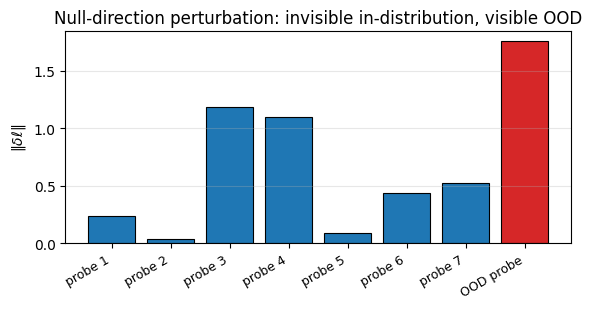

> *Mode 2 in action: the same perturbation, the same model — visible only when the input lies outside the training span.*

In [31]:
step(3, 'Out-of-distribution input: null direction activates')
note('Outside the training distribution v_4 produces a measurable '
     'output change. The covert channel is active on novel inputs.')

y_clean_ood = forward_tanh(W_rect_num, OOD_PROBE_4)
y_pert_ood  = forward_tanh(W_null_pert, OOD_PROBE_4)
delta_ood   = y_pert_ood - y_clean_ood
mag_ood     = float(np.linalg.norm(delta_ood))

display(Math(
    rf'x_{{\mathrm{{OOD}}}} = {latex(Matrix(list(OOD_PROBE_4)))}'
))
display(Math(
    rf'\delta\ell(x_{{\mathrm{{OOD}}}}) = '
    rf'{latex(Matrix(list(np.round(delta_ood, 4))))}'
    rf'\quad \|\delta\ell\| = {mag_ood:.4f} \neq 0'
))

# Compare in-distribution mean vs OOD
in_dist_mag = float(np.mean([
    np.linalg.norm(forward_tanh(W_null_pert, x) - forward_tanh(W_rect_num, x))
    for x in PROBES_4
]))

display(Markdown(
    f'**Comparison:** mean ||δℓ|| on in-distribution probes ≈ '
    f'`{in_dist_mag:.4f}`; on the OOD probe ||δℓ|| ≈ `{mag_ood:.4f}`. '
    f'Ratio = {mag_ood/max(in_dist_mag, 1e-12):.1f}×.'
))

fig, ax = plt.subplots(figsize=(6, 3.2))
labels = [f'probe {i+1}' for i in range(len(PROBES_4))] + ['OOD probe']
vals = [float(np.linalg.norm(forward_tanh(W_null_pert, x) - forward_tanh(W_rect_num, x)))
        for x in PROBES_4] + [mag_ood]
colours = ['#1f77b4'] * len(PROBES_4) + ['#d62728']
ax.bar(range(len(vals)), vals, color=colours, edgecolor='black', linewidth=0.8)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel(r'$\|\delta\ell\|$')
ax.set_title('Null-direction perturbation: invisible in-distribution, visible OOD')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
note('Mode 2 in action: the same perturbation, the same model — '
     'visible only when the input lies outside the training span.')


In [32]:
display(Markdown('---'))
display(Markdown('## Summary'))
display(Markdown('''
| Step | What was shown |
|---|---|
| Gram matrix G = W$^\\top$W | The natural metric on parameter space |
| SVD of W | The canonical perturbation basis (signal + null directions) |
| Jacobian J(x) | How each input maps to output changes |
| Syndrome $s_k = \\mathcal{N}(\\bar{J}\\cdot v_k)$ | The fingerprint of direction $v_k$ |
| Syndrome table $S$ | The complete lookup table |
| σ₄ = 0 in 3×4 case | Null space is guaranteed by dimension counting |
| Oracle correction | Exact restoration when direction is known |
| Crossing error | Wrong correction always increases error |
| Null direction invisible | In-distribution inputs cannot detect null perturbations |
| OOD input activates null | Novel inputs expose the covert channel |
'''))


---

## Summary


| Step | What was shown |
|---|---|
| Gram matrix G = W$^\top$W | The natural metric on parameter space |
| SVD of W | The canonical perturbation basis (signal + null directions) |
| Jacobian J(x) | How each input maps to output changes |
| Syndrome $s_k = \mathcal{N}(\bar{J}\cdot v_k)$ | The fingerprint of direction $v_k$ |
| Syndrome table $S$ | The complete lookup table |
| σ₄ = 0 in 3×4 case | Null space is guaranteed by dimension counting |
| Oracle correction | Exact restoration when direction is known |
| Crossing error | Wrong correction always increases error |
| Null direction invisible | In-distribution inputs cannot detect null perturbations |
| OOD input activates null | Novel inputs expose the covert channel |
